# 05 — Model Explainability (SHAP)

**Goal:** Understand *why* the model makes its predictions using SHAP (SHapley Additive exPlanations).

**Why SHAP over feature importances?**
- Feature importances show average impurity reduction — they don't show *direction* or *magnitude per prediction*
- SHAP values are locally consistent: each value tells you exactly how much that feature pushed the prediction up or down for a specific transaction
- SHAP values sum to the model output — fully additive and interpretable

**Analyses:**
1. Global importance (mean |SHAP|)
2. Summary beeswarm plot (value × direction)
3. Dependence plots for top features
4. Waterfall plot for a single high-risk transaction

In [6]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap

from data_loader import load_engineered, get_split, TARGET
from pipeline import build_preprocessor
from metrics import find_best_threshold, evaluate_model

shap.initjs()
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Load model & prepare data

In [7]:
pipeline = joblib.load('../models/best_pipeline.pkl')
df = load_engineered()
X_train, X_test, y_train, y_test = get_split(df)

# Transform test data using the fitted preprocessor
preprocessor = pipeline.named_steps['preprocess']
X_test_transformed = preprocessor.transform(X_test)

# Recover feature names after preprocessing
ohe = preprocessor.named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(['merchant_category']))

from data_loader import NUMERIC_FEATURES, ENGINEERED_FEATURES, BINARY_FEATURES
all_feature_names = NUMERIC_FEATURES + ENGINEERED_FEATURES + BINARY_FEATURES + cat_feature_names

X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)
print(f'Features after preprocessing: {X_test_df.shape[1]}')

Features after preprocessing: 16


## 2. Compute SHAP values

In [8]:
model = pipeline.named_steps['model']

# TreeExplainer for RF/XGB; use a background sample for efficiency
X_bg = shap.sample(X_test_df, 100, random_state=42)

try:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_df)
    # For binary classifiers, shap_values is a list [class0, class1]
    if isinstance(shap_values, list):
        sv = shap_values[1]   # class 1 = fraud
    else:
        sv = shap_values
    print('Used TreeExplainer')
except Exception:
    explainer = shap.KernelExplainer(model.predict_proba, X_bg)
    sv = explainer.shap_values(X_test_df.iloc[:200])[1]
    print('Used KernelExplainer (slower)')

print(f'SHAP values shape: {sv.shape}')

Used TreeExplainer
SHAP values shape: (2000, 16)


## 3. Global feature importance (mean |SHAP|)

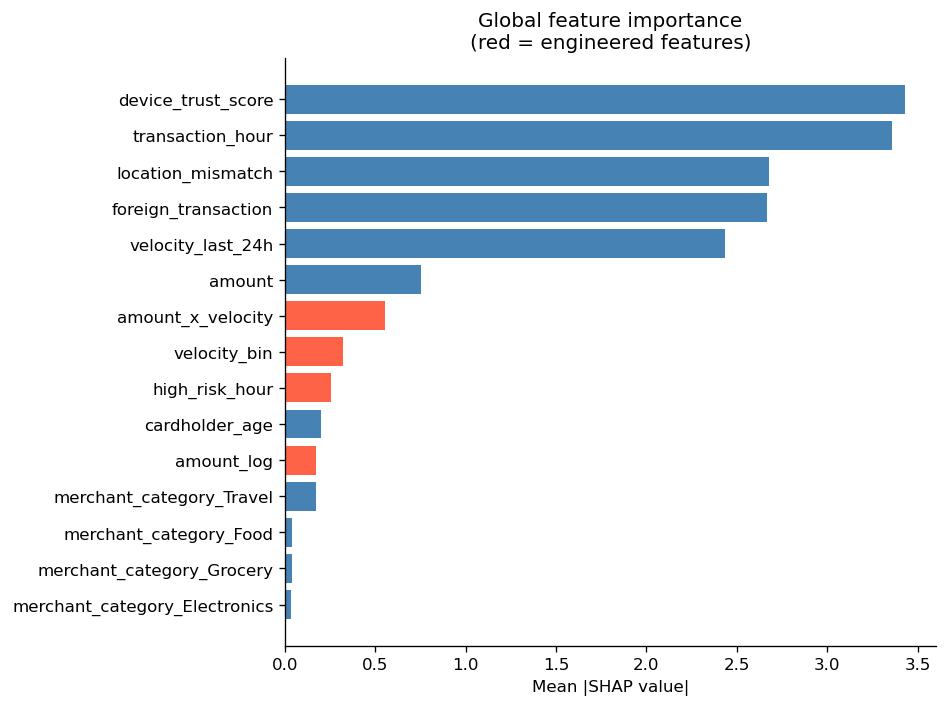

In [10]:
sv_fraud = sv

mean_abs_shap = pd.Series(
    np.abs(sv_fraud).mean(axis=0),
    index=all_feature_names
).sort_values(ascending=True)

# Show top 15 features
top15 = mean_abs_shap.tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if f in ENGINEERED_FEATURES else 'steelblue' for f in top15.index]
ax.barh(top15.index, top15.values, color=colors)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global feature importance\n(red = engineered features)')
plt.tight_layout()
plt.savefig('../reports/figures/05_shap_importance.png', bbox_inches='tight')
plt.show()

## 4. Summary beeswarm plot

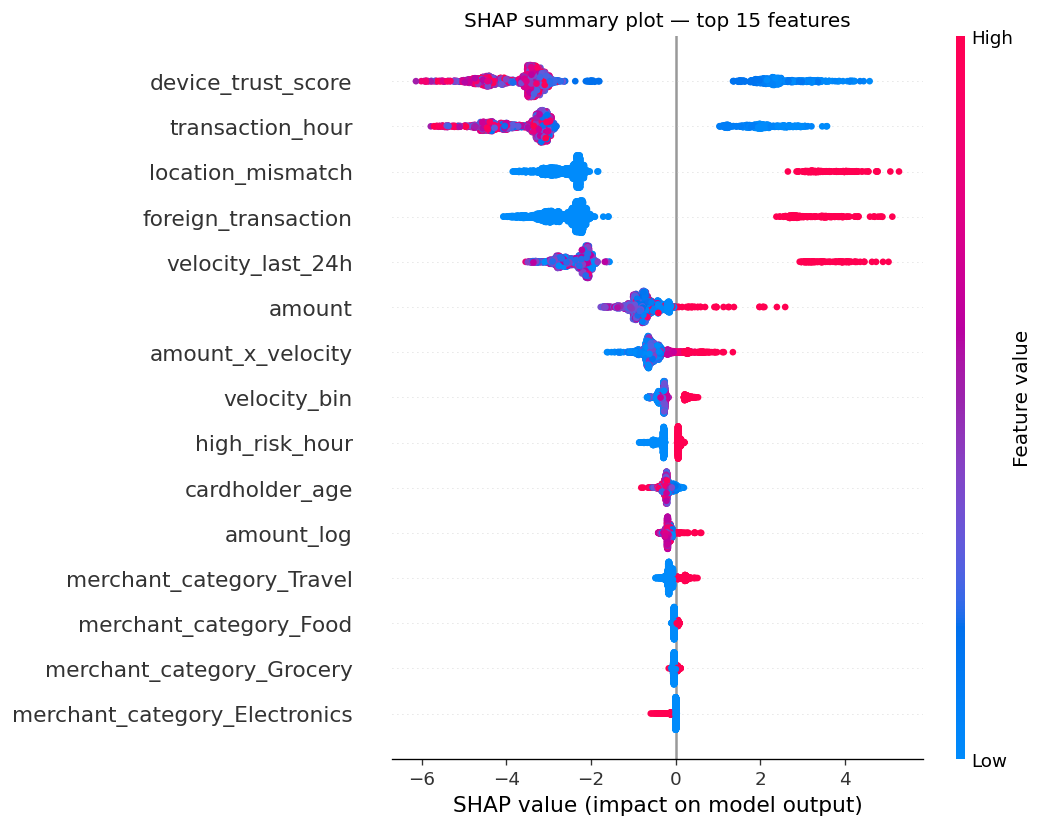

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(
    sv_fraud,
    X_test_df,
    max_display=15,
    plot_type='dot',
    show=False,
    plot_size=None,
)
plt.title('SHAP summary plot — top 15 features')
plt.tight_layout()
plt.savefig('../reports/figures/05_shap_summary.png', bbox_inches='tight')
plt.show()

## 5. Dependence plots for top 2 features

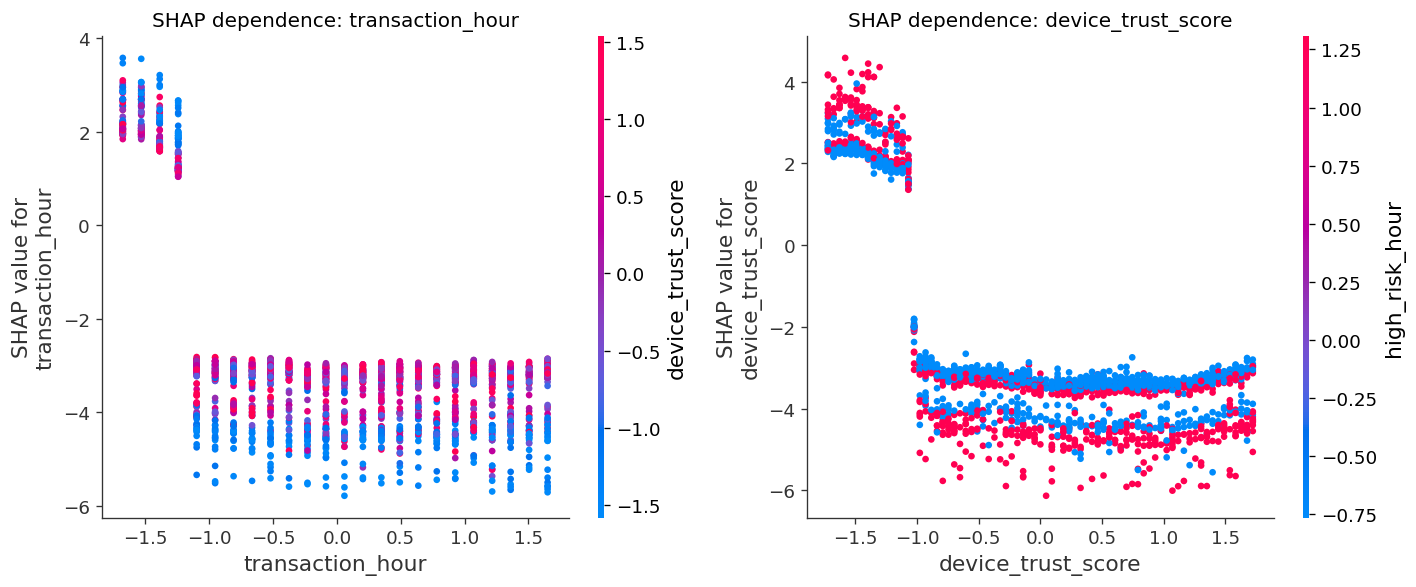

In [12]:
top2 = mean_abs_shap.tail(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat in zip(axes, top2):
    shap.dependence_plot(
        feat, sv_fraud, X_test_df,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP dependence: {feat}')

plt.tight_layout()
plt.savefig('../reports/figures/05_shap_dependence.png', bbox_inches='tight')
plt.show()

## 6. Waterfall plot — single high-risk transaction

Transaction index   : 1301
Predicted fraud prob: 1.0000
Actual label        : FRAUD


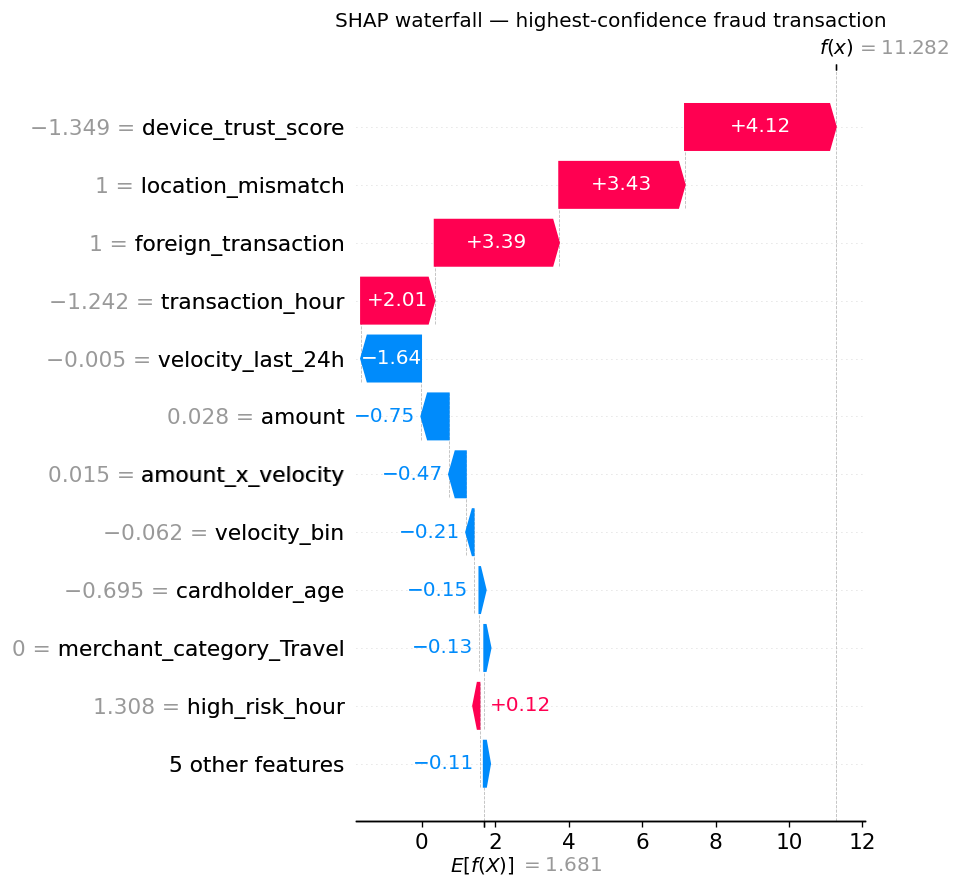

In [13]:
proba_test = pipeline.predict_proba(X_test)[:, 1]
y_test_arr = np.array(y_test)
true_fraud_indices = np.where(y_test_arr == 1)[0]
top_fraud_idx = true_fraud_indices[np.argmax(proba_test[true_fraud_indices])]

print(f'Transaction index   : {top_fraud_idx}')
print(f'Predicted fraud prob: {proba_test[top_fraud_idx]:.4f}')
print('Actual label        : FRAUD')

ev = explainer.expected_value
base_val = float(ev[1]) if hasattr(ev, '__len__') else float(ev)

exp = shap.Explanation(
    values=sv_fraud[top_fraud_idx],
    base_values=base_val,
    data=X_test_df.iloc[top_fraud_idx].values,
    feature_names=all_feature_names,
)

shap.waterfall_plot(exp, max_display=12, show=False)
plt.title('SHAP waterfall — highest-confidence fraud transaction')
plt.tight_layout()
plt.savefig('../reports/figures/05_shap_waterfall.png', bbox_inches='tight')
plt.show()

## Explainability summary

- **Behavioural features dominate**: device trust score, velocity, and the `amount_x_velocity` interaction are consistently the strongest predictors — confirming fraud is about *anomalous behaviour*, not static attributes.
- **Location mismatch and foreign transaction** contribute meaningfully but are not top-ranked by SHAP — their impact is conditional on other features.
- **Engineered features earn their place**: `amount_x_velocity` and `amount_log` appear in the top 15 by mean |SHAP|, validating the feature engineering step.
- **Actionable for ops teams**: The waterfall plot can be generated in real-time for any flagged transaction, giving analysts a clear breakdown of *why* the model flagged it.